In [1]:
import sys
import torch
import polars as pl

from modeling_module.data_loader.MultiPartDataModule import MultiPartDataModule

'''
pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
https://developer.nvidia.com/cuda-12-8-0-download-archive
'''

MAC_DIR = '/Users/igwanhyeong/PycharmProjects/data_research/raw_data/'
WINDOW_DIR = 'C:/Users/USER/PycharmProjects/research/raw_data/'

if sys.platform == 'win32':
    DIR = WINDOW_DIR
    print(torch.cuda.is_available())
    print(torch.cuda.device_count())
    print(torch.version.cuda)
    print(torch.__version__)
    print(torch.cuda.get_device_name(0))
    print(torch.__version__)
else:
    DIR = MAC_DIR

In [2]:
target_dyn_demand_weekly = pl.read_parquet(DIR + 'target_dyn_demand_weekly.parquet')
target_dyn_demand_weekly

oper_part_no,demand_dt,demand_qty
str,i64,f64
"""E5500-73432""",202223,70.0
"""T2555-24281""",202237,1.0
"""CZ11-0092D""",201936,12.0
"""T4340-37431""",201813,1.0
"""T2350-95424BB""",201909,1.0
…,…,…
"""04810-00280""",202208,50.0
"""T4125-75893BB""",202033,1.0
"""T4684-31052""",202314,1.0


In [3]:
from modeling_module.models.PatchTST.supervised.backbone import SupervisedBackbone
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigWeekly

cfg = PatchTSTConfigWeekly(
    c_in=1,
    target_dim=1,
    lookback=54,
    horizon=27,
    patch_len=4,
    stride=2,
)

model = SupervisedBackbone(cfg)
x = torch.randn(8, cfg.c_in, cfg.lookback)
out = model(x)

print(out.shape)  # [8, L_tok, d_model]

torch.Size([8, 26, 128])


In [4]:
plan_yyyymm = 201811
lookback = 54
horizon = 27

data_module = MultiPartDataModule(
    target_dyn_demand_weekly.sort(['oper_part_no', 'demand_dt']),
    lookback = lookback,
    horizon = horizon,
    batch_size = 64,
    val_ratio = 0.2,
    is_running = True
)

train_loader = data_module.get_train_loader()
val_loader = data_module.get_val_loader()

In [5]:
from modeling_module.training.model_trainers.total_train import run_total_train_monthly

mode_dict = run_total_train_monthly(
    train_loader,
    val_loader,
    lookback = lookback,
    horizon = horizon,
)



27
PatchMixer Quantile


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/amp/grad_scaler.py:136: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


Epoch 1/1 | LR 0.000976 | Train 15.596300 | Val 14.907444
Titan Patch
Epoch 1/1 | LR 0.000976 | Train 81.424233 | Val 78.064700
PatchTST Base
Epoch 1/1 | LR 0.000976 | Train 20.236706 | Val 19.628026
PatchTST Quantile
Epoch 1/1 | LR 0.000976 | Train 20.026701 | Val 19.631320


In [6]:
from modeling_module.utils.checkpoint import save_model_dict, load_model_dict
from modeling_module.utils.exogenous_utils import calendar_cb
from modeling_module.models.PatchTST.common.configs import PatchTSTConfigMonthly
from modeling_module.models.Titan.common.configs import TitanConfigMonthly, TitanConfigPatchMonthly
from modeling_module.models.PatchMixer.common.configs import PatchMixerConfigMonthly

save_dir = DIR + 'fit/20251101_running'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

pm_base_config = PatchMixerConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

pm_quantile_config = PatchMixerConfigMonthly(
    device = device,
    loss_mode = 'quantile',
    quantiles = (0.1, 0.5, 0.9)
)

ti_config = TitanConfigMonthly(
        device = device,
        loss_mode = 'point',
        point_loss = 'mae'
    )

ti_patch_config = TitanConfigPatchMonthly(
    device = device,
    loss_mode = 'point',
    point_loss = 'mae'
)

pt_config = PatchTSTConfigMonthly(
        device = device,
        loss_mode = 'auto',
        quantiles = (0.1, 0.5, 0.9)
    )

cfg_map = {
    "PatchMixer Base": pm_base_config,
    "PatchMixer Quantile": pm_quantile_config,
    "Titan Base": ti_config,
    "Titan LMM": ti_config,
    "Titan Seq2Seq": ti_config,
    "Titan Patch": ti_patch_config,
    "PatchTST Base": pt_config,
    "PatchTST Quantile": pt_config
}

builder_key_by_name = {
  "PatchMixer Base": "patchmixer_base",
  "PatchMixer Quantile": "patchmixer_quantile",
  "Titan Base": "titan_base",
  "Titan LMM": "titan_lmm",
  "Titan Seq2Seq": "titan_seq2seq",
  "Titan Patch": "titan_patch",
  "PatchTST Base": "patchtst_base",
  "PatchTST Quantile": "patchtst_quantile",
}
save_index = save_model_dict(mode_dict, save_dir, cfg_by_name = cfg_map, builder_key_by_name=builder_key_by_name)

# Load
from modeling_module.models.model_builder import (
    build_patch_mixer_base, build_patch_mixer_quantile,
    build_titan_base, build_titan_lmm, build_titan_seq2seq,
    build_patchTST_base, build_patchTST_quantile, build_titan_patch,
)

builders = {
    # "patchmixer_base": lambda cfg: build_patch_mixer_base(cfg or PatchMixerConfigMonthly()),
    "patchmixer_quantile": lambda cfg: build_patch_mixer_quantile(cfg or PatchMixerConfigMonthly()),
    # "titan_base": lambda cfg: build_titan_base(cfg or TitanConfigMonthly()),
    # "titan_lmm": lambda cfg: build_titan_lmm(cfg or TitanConfigMonthly()),
    # "titan_seq2seq": lambda cfg: build_titan_seq2seq(cfg or TitanConfigMonthly()),
    'titan_patch': lambda cfg: build_titan_patch(cfg or TitanConfigPatchMonthly()),
    "patchtst_base": lambda cfg: build_patchTST_base(cfg or PatchTSTConfigMonthly()),
    "patchtst_quantile": lambda cfg: build_patchTST_quantile(cfg or PatchTSTConfigMonthly()),
}
loaded = load_model_dict(save_dir, builders, device = device)



[load] patchmixer_quantile ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251101_running/patchmixer_quantile.pt
27
[load] titan_patch ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251101_running/titan_patch.pt
[load] patchtst_base ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251101_running/patchtst_base.pt
[load] patchtst_quantile ← /Users/igwanhyeong/PycharmProjects/data_research/raw_data/fit/20251101_running/patchtst_quantile.pt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
model PatchMixer QuantileModel [DBG] t 0 q10: 1.3480556011199951 q50: 2.632223606109619 q90: 9.015840530395508
model PatchMixer QuantileModel [DBG] t 1 q10: 1.1732628345489502 q50: 2.43904185295105 q90: 8.755130767822266
model PatchMixer QuantileModel [DBG] t 2 q10: 1.1089215278625488 q50: 2.5787365436553955 q90: 8.52081298828125
model PatchMixer QuantileModel [DBG] t 3 q10: 1.0773885250091553 q50: 2.6082592010498047 q90: 9.268305778503418
model PatchMixer QuantileModel [DBG] t 4 q10: 1.085740566253662 q50: 2.6260011196136475 q90: 10.16629409790039
model PatchTST QuantileModel [DBG] t 0 q10: 3.5632362365722656 q50: 4.0451250076293945 q90: 4.084397792816162
model PatchTST QuantileModel [DBG] t 1 q10: 3.5102765560150146 q50: 3.9913196563720703 q90: 4.031003475189209
model PatchTST QuantileModel [DBG] t 2 q10: 3.5698094367980957 q50: 4.048184871673584 q90: 4.087836265563965
model PatchTST QuantileModel

ValueError: 'x' has size 27, but 'y1' has an unequal size of 120

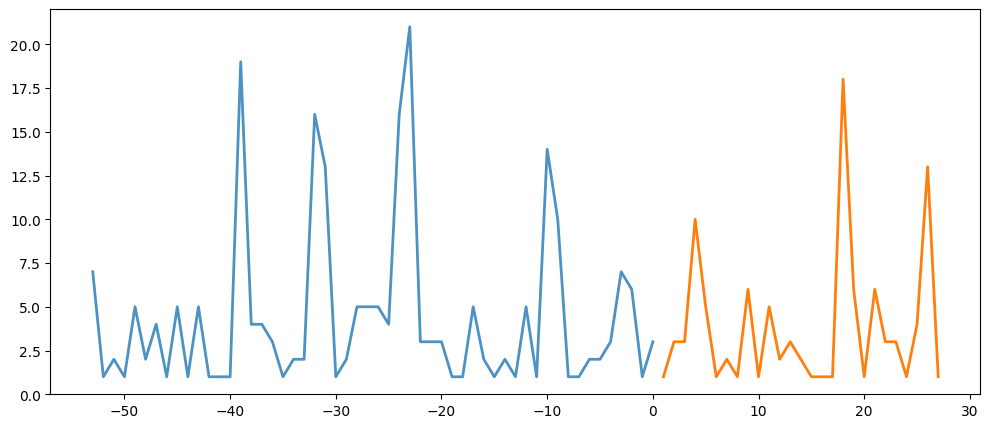

In [9]:
%load_ext autoreload
%autoreload 2

import importlib
import modeling_module.utils.plot_utils as plot_utils
importlib.reload(plot_utils)

plot_utils.plot_120_months_many(
    loaded, val_loader, device = device, use_truth = True,
    max_plots = 100, show = True, future_exo_cb=calendar_cb
)